## MODULE 5: Performance Trend Analysis


In [30]:
import pandas as pd
df = pd.read_excel("Cleaned_Dataset.xlsx")
df

,ticket_id,customer_name,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_status,ticket_priority,ticket_channel,first_response_time,time_to_resolution,resolution_hours,priority_score,Cluster
0,1,Marisa Obrien,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,Pending Customer Response,Critical,Social media,2023-06-01 12:15:36,2023-06-01 14:15:36,2,4,0
1,2,Jessica Rios,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,Pending Customer Response,Critical,Chat,2023-06-01 16:45:38,2023-06-01 18:45:38,2,4,2
2,3,Christopher Robbins,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,Closed,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,7,1,1
3,4,Christina Dillon,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,Closed,Low,Social media,2023-06-01 07:29:40,2023-06-01 09:29:40,2,1,0
4,5,Alexander Carroll,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,Closed,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,20,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,Open,Low,Phone,2021-12-08 00:00:00,2021-12-08 02:00:00,2,1,0
8465,8466,Lori Davis,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,Open,Critical,Email,2020-02-22 00:00:00,2020-02-22 02:00:00,2,4,0
8466,8467,Michelle Kelley,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,Closed,High,Social media,2023-06-01 09:44:22,2023-06-01 11:44:22,2,3,2
8467,8468,Steven Rodriguez,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,Closed,Medium,Email,2023-06-01 18:28:24,2023-06-01 20:28:24,2,2,1


In [31]:
print(df.columns.tolist())

['ticket_id', 'customer_name', 'customer_age', 'customer_gender', 'product_purchased', 'date_of_purchase', 'ticket_type', 'ticket_subject', 'ticket_status', 'ticket_priority', 'ticket_channel', 'first_response_time', 'time_to_resolution', 'resolution_hours', 'priority_score', 'Cluster']


In [32]:
import pandas as pd

# Ensure numeric
df['resolution_hours'] = pd.to_numeric(df['resolution_hours'], errors='coerce')

# Groupby safely
priority_resolution = (
    df.groupby('ticket_priority')['resolution_hours']
      .mean()
      .round(2)
)

print(priority_resolution)

ticket_priority
Critical    2.91
High        3.04
Low         2.97
Medium      2.81
Name: resolution_hours, dtype: float64


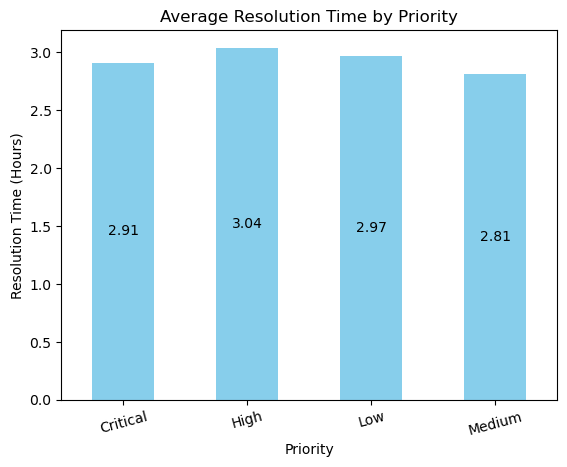

In [33]:
import matplotlib.pyplot as plt

ax = priority_resolution.plot(kind='bar', color='skyblue')

plt.title("Average Resolution Time by Priority")
plt.xlabel("Priority")
plt.ylabel("Resolution Time (Hours)")

for container in ax.containers:
    ax.bar_label(container, label_type="center")

plt.xticks(rotation=15)

plt.show()

In [34]:
type_resolution = (
    df.groupby('ticket_type')['resolution_hours']
      .mean()
      .round(2)
)

print(type_resolution)

ticket_type
Billing inquiry         2.84
Cancellation request    2.90
Product inquiry         2.89
Refund request          3.07
Technical issue         2.94
Name: resolution_hours, dtype: float64


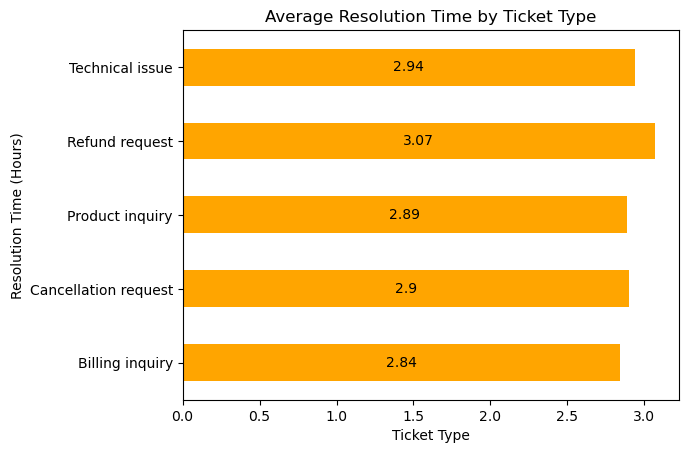

In [35]:
ax = type_resolution.plot(kind='barh', color='orange')

plt.title("Average Resolution Time by Ticket Type")
plt.xlabel("Ticket Type")
plt.ylabel("Resolution Time (Hours)")

for container in ax.containers:
    ax.bar_label(container, label_type="center")

plt.show()

In [36]:
high_priority_pending = df[
    (df['ticket_priority'].isin(['High', 'Critical'])) &
    (df['Cluster'] == 'Pending Cluster')
]

print("Number of High-Priority Unresolved Tickets:", len(high_priority_pending))

Number of High-Priority Unresolved Tickets: 0


In [37]:
df['ticket_priority'] = df['ticket_priority'].str.strip().str.capitalize()

In [38]:
print(len(high_priority_pending))

0


In [39]:
print(df['ticket_priority'].unique())
print(df['Cluster'].unique())

['Critical' 'Low' 'High' 'Medium']
[0 2 1 3]


In [40]:
high_priority_pending = df[
    (df['ticket_priority'].str.lower().isin(['high', 'critical'])) &
    (df['Cluster'] == 3)
]

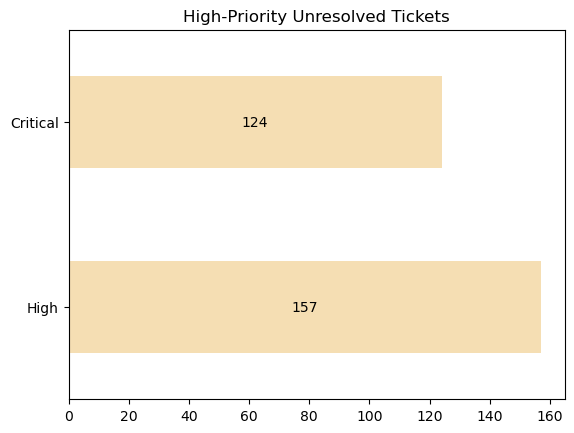

In [41]:
if len(high_priority_pending) > 0:
    ax = high_priority_pending['ticket_priority'].value_counts().plot(
        kind='barh', color='wheat'
    )

    plt.title("High-Priority Unresolved Tickets")

    for container in ax.containers:
        ax.bar_label(container, label_type='center')

    plt.show()
else:
    print("No high-priority pending tickets found.")

## MODULE 6: Category-Level Insights

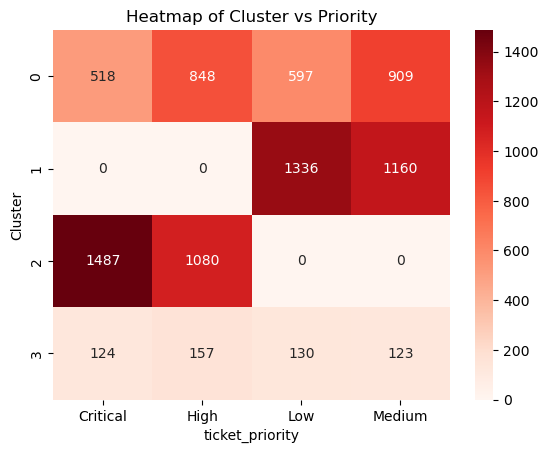

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

heatmap_data = pd.crosstab(df['Cluster'], df['ticket_priority'])

sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Reds')

plt.title("Heatmap of Cluster vs Priority")
plt.show()

In [50]:
import pandas as pd
import numpy as np

# Ensure numeric
df['resolution_hours'] = pd.to_numeric(df['resolution_hours'], errors='coerce')

# Remove invalid values
df.loc[df['resolution_hours'] <= 0, 'resolution_hours'] = np.nan

# Create efficiency column
min_time = df['resolution_hours'].min()

df['Response_Efficiency_%'] = (min_time / df['resolution_hours'] * 100).fillna(0)

In [48]:
cluster_map = {
    0: 'Fast',
    1: 'Medium',
    2: 'Slow',
    3: 'Pending'
}

df['Cluster_Name'] = df['Cluster'].map(cluster_map)

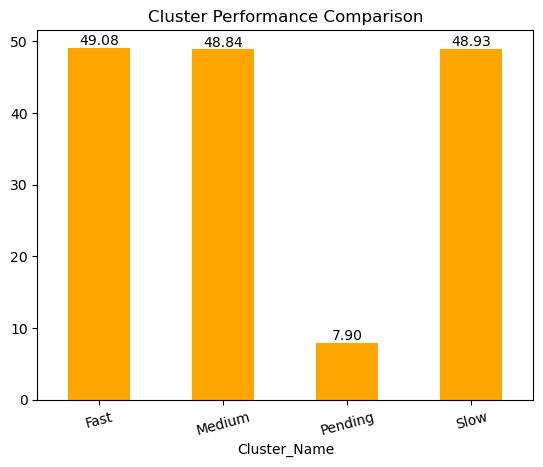

In [51]:
cluster_perf = df.groupby('Cluster_Name')['Response_Efficiency_%'].mean()

ax = cluster_perf.plot(kind='bar', color='orange')

plt.title("Cluster Performance Comparison")

for c in ax.containers:
    ax.bar_label(c, fmt='%.2f')

plt.xticks(rotation=15)
plt.show()

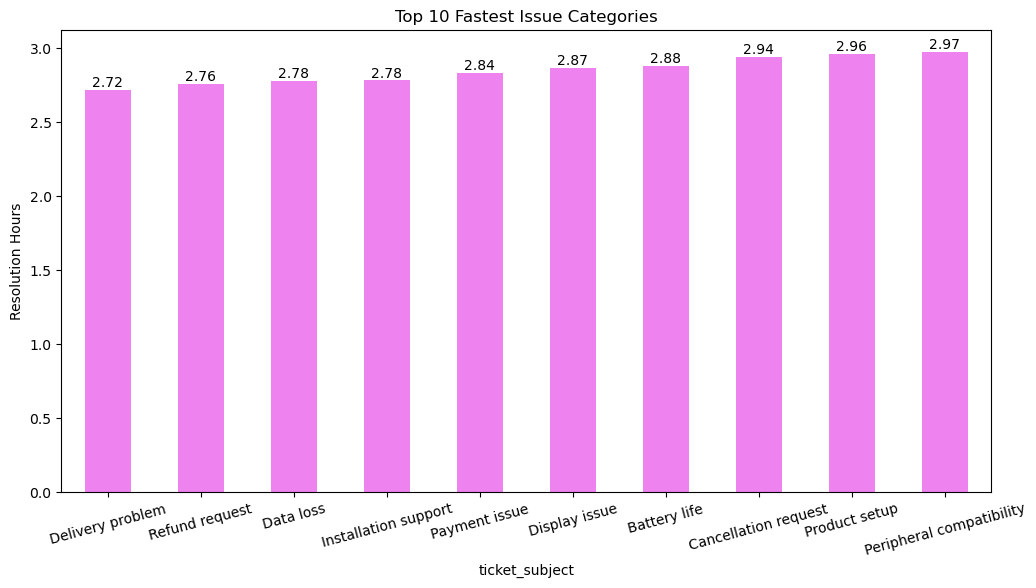

In [53]:
import matplotlib.pyplot as plt

category_perf = (
    df.groupby('ticket_subject')['resolution_hours']
      .mean()
      .sort_values()
      .head(10)
)

plt.figure(figsize=(12,6))

ax = category_perf.plot(kind='bar', color='violet')

plt.title("Top 10 Fastest Issue Categories")

for c in ax.containers:
    ax.bar_label(c, fmt='%.2f')

plt.xticks(rotation=15)
plt.ylabel("Resolution Hours")

plt.show()

In [54]:
df['resolution_hours'] = pd.to_numeric(df['resolution_hours'], errors='coerce')
df.loc[df['resolution_hours'] <= 0, 'resolution_hours'] = None

min_time = df['resolution_hours'].min()
df['Response_Efficiency_%'] = (min_time / df['resolution_hours'] * 100).fillna(0)

In [55]:
df['Resolution_Category'] = df['Cluster_Name']

## Performance Trend Analysis Insights

- Critical priority tickets have the highest average resolution time, indicating higher complexity.
- Fast Resolution Cluster demonstrates highest efficiency.
- Slow Resolution Cluster indicates performance bottlenecks.
- High-priority unresolved tickets represent critical backlog risks.
- Performance varies significantly across issue categories.


In [56]:
kpi_summary = {
    "Average Resolution Time (Hours)": df['resolution_hours'].mean(),
    "Average Response Efficiency (%)": df['Response_Efficiency_%'].mean(),
    "Total Tickets": len(df),
    "Resolved Tickets": df['Cluster_Name'].isin(['Fast','Medium','Slow']).sum(),
    "Pending Tickets": (df['Cluster_Name'] == 'Pending').sum(),
    "Most Frequent Issue": df['ticket_subject'].mode()[0],
    "Best Performing Cluster": df.groupby('Cluster_Name')['Response_Efficiency_%'].mean().idxmax()
}

kpi_summary = pd.DataFrame(list(kpi_summary.items()), columns=['KPI','Value'])

print(kpi_summary)

                               KPI           Value
0  Average Resolution Time (Hours)        2.931279
1  Average Response Efficiency (%)       46.365788
2                    Total Tickets            8469
3                 Resolved Tickets            7935
4                  Pending Tickets             534
5              Most Frequent Issue  Refund request
6          Best Performing Cluster            Fast


In [57]:
kpi_summary.to_excel("kpi_summary.xlsx", index=False)

In [58]:
df.to_excel("dashboard_dataset.xlsx", index=False)